## Lab6

In this problem you will develop models to predict whether a given car gets high or low gas mileage based on the  `Auto.csv` data set. Load the data and name the resulting DataFrame `Auto`.

In [1]:
# import your libraries here
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize)

from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
     (LinearDiscriminantAnalysis as LDA,
      QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

Auto = pd.read_csv('../Data/Auto.csv', na_values='?')
Auto = Auto.dropna()
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


**(a) Add a column called `mpg01` to `Auto` that contains a `1` if `mpg` contains a value above its median, and a `0` if `mpg` contains a value below its median.**

*Note: remember to remove the non-numeric values from the `horsepower` column.*

In [2]:
Auto['mpg01'] = (Auto.mpg > Auto.mpg.median()).astype(int)
print(f'Median: {Auto.mpg.median()}')
Auto.head()

Median: 22.75


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,mpg01
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu,0
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320,0
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite,0
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst,0
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino,0


**(b) Explore the data in order to investigate the association between `mpg01` and the other features. Which of the other features seem most likely to be useful in predicting `mpg01`?**

In [3]:
allvars = Auto.columns.drop(['mpg','name', 'mpg01'])
design = MS(allvars)
X = design.fit_transform(Auto)
y = Auto.mpg01 == 1
glm = sm.GLM(y,X,family=sm.families.Binomial())
results = glm.fit()
print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  mpg01   No. Observations:                  392
Model:                            GLM   Df Residuals:                      384
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -78.770
Date:                Wed, 29 Oct 2025   Deviance:                       157.54
Time:                        12:52:16   Pearson chi2:                     309.
No. Iterations:                     8   Pseudo R-squ. (CS):             0.6263
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      -17.1549      5.764     -2.976   

Based on the general linear model results the predictors most useful for predicting mpg01 are weight and year as their respective p values are below 0.05. But for the purposes of later questions we will use the 4 predictors with the lowes p values. (weight, year, horsepower, and origin)

**(c) Using the four variables that seemed most associated with `mpg01` in (b), split the data into a training set and a test set using the `train_test_split` function from the `sklearn.model_selection` module in Python. This function randomly divides your dataset into two parts, one for training the model and the other for testing its performance on unseen data.**

*Note: The basic syntax is*

    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
    )
*where `X` is the feature matrix (predictors), `y` is the target variable (response), `test_size`is the fraction of data to reserve for testing (e.g., 0.3 = 30%), and `random_state` is a random seed for reproducibility (using the same value ensures that everyone gets the same split). Here use `test_size=0.2` and `random_state=1`*.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1)

In [5]:
# creating an array to store values for ROC curves
probs_array = []

**(d) Perform logistic regression on the training data in order to predict `mpg01` using the four variables that seemed most associated with `mpg01` in (b). What is the test accuracy of the model obtained?**

In [6]:
glm = sm.GLM(y_train,
             X_train,
             family=sm.families.Binomial())
results = glm.fit()
probs_train = results.predict(X_train)
probs_test = results.predict(X_test)
probs_array.append(probs_test)
pred_bool_train = probs_train > 0.5
pred_bool_test = probs_test > 0.5

confusionTable = confusion_table(pred_bool_train, y_train)
print(confusionTable)
print(f'Training accuracy: {np.mean(y_train == pred_bool_train) * 100:.2f}%')

Truth      False  True 
Predicted              
False        130     13
True          21    149
Training accuracy: 89.14%


In [7]:
confusionTable = confusion_table(pred_bool_test, y_test)
print(confusionTable)
print(f'Testing accuracy: {np.mean(y_test == pred_bool_test) * 100:.2f}%')

Truth      False  True 
Predicted              
False         44      2
True           1     32
Testing accuracy: 96.20%


**(e) Repeat (d) using LDA.**

In [8]:
lda = LDA(store_covariance=True)
lda.fit(X_train, y_train)

pred_train = lda.predict(X_train)
pred_test = lda.predict(X_test)
probs_array.append(pred_test)

confusionTable = confusion_table(pred_train, y_train)
print(confusionTable)
print(f'Training accuracy: {np.mean(y_train == pred_train) * 100:.2f}%')

Truth      False  True 
Predicted              
False        122      6
True          29    156
Training accuracy: 88.82%


In [9]:
confusionTable = confusion_table(pred_test, y_test)
print(confusionTable)
print(f'Testing accuracy: {np.mean(y_test == pred_test) * 100:.2f}%')

Truth      False  True 
Predicted              
False         42      0
True           3     34
Testing accuracy: 96.20%


**(f) Repeat (d) using QDA.**

In [10]:
qda = QDA(store_covariance=True)
qda.fit(X_train, y_train)

pred_train = qda.predict(X_train)
pred_test = qda.predict(X_test)
probs_array.append(pred_test)

confusionTable = confusion_table(pred_train, y_train)
print(confusionTable)
print(f'Training accuracy: {np.mean(y_train == pred_train) * 100:.2f}%')

Truth      False  True 
Predicted              
False        151    162
True           0      0
Training accuracy: 48.24%


C:\Users\William\AppData\Roaming\Python\Python313\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
C:\Users\William\AppData\Roaming\Python\Python313\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
C:\Users\William\AppData\Roaming\Python\Python313\site-packages\sklearn\discriminant_analysis.py:1052: RuntimeWarning: divide by zero encountered in power
  X2 = np.dot(Xm, R * (S ** (-0.5)))
C:\Users\William\AppData\Roaming\Python\Python313\site-packages\sklearn\discriminant_analysis.py:1052: RuntimeWarning: invalid value encountered in multiply
  X2 = np.dot(Xm, R * (S ** (-0.5)))
C:\Users\William\AppData\Roaming\Python\Python313\site-packages\sklearn\di

In [11]:
confusionTable = confusion_table(pred_test, y_test)
print(confusionTable)
print(f'Testing accuracy: {np.mean(y_test == pred_test) * 100:.2f}%')

Truth      False  True 
Predicted              
False         45     34
True           0      0
Testing accuracy: 56.96%


**(g) Repeat (d) using Naive Bayes.**

In [12]:
NB = GaussianNB()
NB.fit(X_train, y_train)
pred_train = NB.predict(X_train)
pred_test = NB.predict(X_test)
probs_array.append(pred_test)
print(confusion_table(pred_train, y_train))
print(f'Training accuracy: {np.mean(y_train == pred_train) * 100:.2f}%')

Truth      False  True 
Predicted              
False        127      9
True          24    153
Training accuracy: 89.46%


In [13]:
print(confusion_table(pred_test, y_test))
print(f'Testing accuracy: {np.mean(y_test == pred_test) * 100:.2f}%')

Truth      False  True 
Predicted              
False         42      2
True           3     32
Testing accuracy: 93.67%


**(h) Repeat (d) using KNN trying various values of K. Which value of K achieves the highest test accuracy?**

In [14]:
for K in range(1,10):
    knn = KNeighborsClassifier(n_neighbors=K)
    knn_pred = knn.fit(X_train, y_train).predict(X_test)
    C = confusion_table(knn_pred, y_test)
    accuracy = np.mean(y_test == knn_pred)
    print(f'K = {K}: # Testing accuracy: {accuracy * 100:.5f}%')
    if(K==8):
        probs_array.append(knn_pred)

K = 1: # Testing accuracy: 87.34177%
K = 2: # Testing accuracy: 87.34177%
K = 3: # Testing accuracy: 89.87342%
K = 4: # Testing accuracy: 89.87342%
K = 5: # Testing accuracy: 87.34177%
K = 6: # Testing accuracy: 89.87342%
K = 7: # Testing accuracy: 87.34177%
K = 8: # Testing accuracy: 91.13924%
K = 9: # Testing accuracy: 91.13924%


**(i) Plot the ROC curves and compute the corresponding AUC (Area Under the Curve) values for the models from (d)-(h). For KNN use the optimal value of K from (h). Comment on your findings.**

Logistic Regression roc score: 0.9947712418300654
LDA roc score: 0.9666666666666667
QDA roc score: 0.5
Naive Bayes roc score: 0.9372549019607843
KNN(k=8) roc score: 0.907843137254902


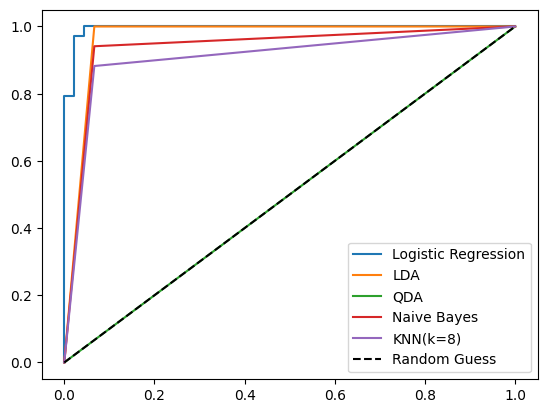

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

labels = ['Logistic Regression', 'LDA', 'QDA', 'Naive Bayes', 'KNN(k=8)']

for i in range(0, len(probs_array)):
    y_test_num = (y_test).astype(int)
    fpr, tpr, _ = roc_curve(y_test_num, probs_array[i])
    auc = roc_auc_score(y_test_num, probs_array[i])
    print(f'{labels[i]} roc score: {auc}')
    plt.plot(fpr, tpr, label=labels[i])

plt.plot([0,1],[0,1],'k--',label='Random Guess')
plt.legend()

Based on the ROC curves logistic regression and LDA performed the best. With logistic regression being the best with a score of 0.9948 which is very impressive. QDA performed the worse with and roc score of 0.5 meaning it is by far the worst of these models for this dataset.